# Example

<IPython.core.display.Javascript object>


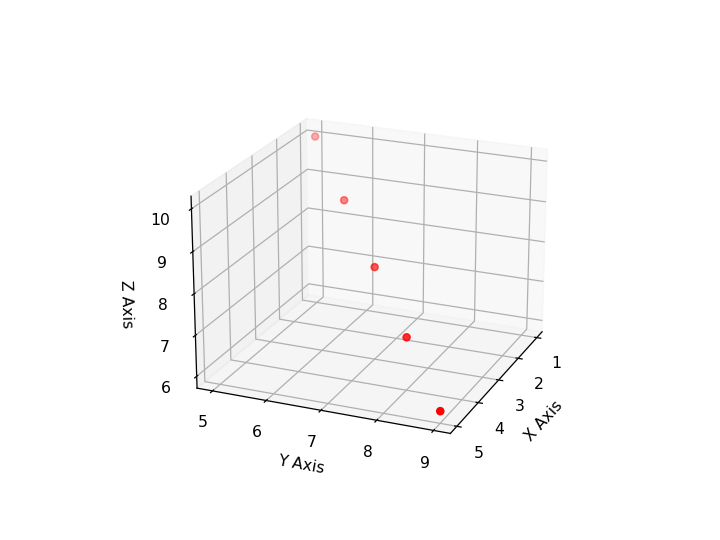

In [34]:

%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = [1, 2, 3, 4, 5]
y = [5, 6, 7, 8, 9]
z = [10, 9, 8, 7, 6]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='r', marker='o')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.show()


# Implementation

In [27]:
import json

with open('my_project/controllers/my_controller/learnt_policies.json', 'r') as f:
    data = json.load(f)

all_trajectories = []

for policy in data:
    trajectory = [policy["Coordinates"][0]] +  policy["SetPairs"][1:] +[policy["Coordinates"][1]]
    
    all_trajectories.append(trajectory)
    
print(all_trajectories)

[[[13, 10], [4, 10], [3, 16], [6, 18], [8, 6], [2, 4], [13, 11], [1, 3], [6, 16], [13, 10], [5, 10], [12, 15]]]


In [28]:
from minisom import MiniSom
import pickle
import csv
import numpy as np

with open('my_project/controllers/my_controller/somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

gps_data=[]
with open("my_project/controllers/my_controller/gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        gps_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
                

weights_som = somVisual.get_weights()

def get_coordinate(input):
    som_winner =weights_som[input[0], input[1]]
    return som_winner

#denormalize a vector given dataset
def denormalize_vector(normalized_vector, data):
    # Calculate min and max for each feature in the dataset
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Denormalize the vector
    denormalized_vector = []
    for i in range(len(normalized_vector)):
        denormalized_value = normalized_vector[i] * (max_values[i] - min_values[i]) + min_values[i]
        denormalized_vector.append(denormalized_value)
    return denormalized_vector



all_coordinates= []
for trajectory in all_trajectories:
    new_coordinates=[]
    for coordinate in trajectory:
        new_coord=get_coordinate(coordinate)
        new_coord=list(new_coord)
        new_coord=denormalize_vector(new_coord, gps_data)
        new_coordinates.append(new_coord) 
    all_coordinates.append(new_coordinates)
    
print(all_coordinates)

[[[0.20542129279807017, -0.18324136173448416, 0.10238949711208045], [0.2288917113556218, -0.1370575859270899, 0.07641195779891646], [0.2043959384416961, -0.13926106194660123, 0.015971849525449527], [0.20336279603871737, -0.15656099195264717, 0.021721001612082583], [0.2244268144558061, -0.1488750123743493, 0.12913630358049868], [0.23845866005822977, -0.10951949833591887, 0.12644770778946396], [0.20331631672109846, -0.1867800803825922, 0.08847817968366706], [0.685471778023649, 0.3938949924038571, 0.8166242715715621], [0.21003102482109498, -0.15524723777353477, 0.03178017211249935], [0.20542129279807017, -0.18324136173448416, 0.10238949711208045], [0.2294703688467254, -0.14586519461958003, 0.07831925405031778], [0.19698667788510205, -0.1810530551284621, 0.03644485143285754]]]


<IPython.core.display.Javascript object>


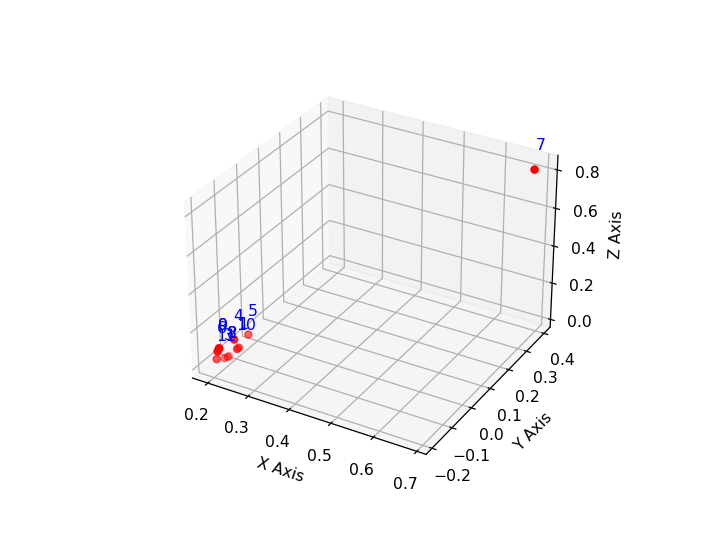

In [29]:
%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

for i in range(len(all_coordinates)):
    trajectory_to_plot= all_coordinates[i]

    x = []
    y = []
    z = []

    for coordinate in trajectory_to_plot:
        x.append(coordinate[0])
        y.append(coordinate[1])
        z.append(coordinate[2])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x, y, z, c='r', marker='o')
    
    for index, (x_coord, y_coord, z_coord) in enumerate(trajectory_to_plot):
        ax.text(x_coord, y_coord, z_coord + 0.1, str(index), color='blue')  # Adjust z + 0.1 to position text above the point


    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')

    plt.show()

In [24]:
def evaluate_buffer( buffer):
    # Condition 3: Verify if the buffer is strictly decreasing or non-increasing
    is_decreasing = all(buffer[i] >= buffer[i+1] for i in range(len(buffer)-1))
    
    return is_decreasing

buffer =[
            0.034113726062214675,
            0.03410703830089497,
            0.034101720932810026,
            0.034097486430111436,
            0.0340940911238539,
            0.03409139038819758,
            0.0340892711215697,
            0.034087546216764505,
            0.028529815183484655,
            0.014128474767627621,
            0.012757636554861574
        ]
is_decreasing = evaluate_buffer(buffer)

if is_decreasing:
    print(f"Buffer is decreasing")
else:
    print("Buffer is not decreasing.")

Buffer is decreasing


In [30]:
import math

# Lista de coordenadas tridimensionales
coordenadas =[[0.20542129279807017, -0.18324136173448416, 0.10238949711208045], [0.2288917113556218, -0.1370575859270899, 0.07641195779891646], [0.2043959384416961, -0.13926106194660123, 0.015971849525449527], [0.20336279603871737, -0.15656099195264717, 0.021721001612082583], [0.2244268144558061, -0.1488750123743493, 0.12913630358049868], [0.23845866005822977, -0.10951949833591887, 0.12644770778946396], [0.20331631672109846, -0.1867800803825922, 0.08847817968366706], [0.685471778023649, 0.3938949924038571, 0.8166242715715621], [0.21003102482109498, -0.15524723777353477, 0.03178017211249935], [0.20542129279807017, -0.18324136173448416, 0.10238949711208045], [0.2294703688467254, -0.14586519461958003, 0.07831925405031778], [0.19698667788510205, -0.1810530551284621, 0.03644485143285754]]
# Tomamos la última coordenada como referencia
ultima_coordenada = coordenadas[-1]

# Función para calcular la distancia euclidiana
def distancia_euclidiana(coord1, coord2):
    return math.sqrt(sum((c1 - c2)**2 for c1, c2 in zip(coord1, coord2)))

# Calcular y mostrar la distancia euclidiana de cada coordenada a la última
for i, coord in enumerate(coordenadas[:-1]):  # Excluimos la última coordenada
    distancia = distancia_euclidiana(coord, ultima_coordenada)
    print(f"Distancia de la coordenada {i+1} a la última coordenada: {distancia:.6f}")


Distancia de la coordenada 1 a la última coordenada: 0.066518
Distancia de la coordenada 2 a la última coordenada: 0.067460
Distancia de la coordenada 3 a la última coordenada: 0.047123
Distancia de la coordenada 4 a la última coordenada: 0.029280
Distancia de la coordenada 5 a la última coordenada: 0.101883
Distancia de la coordenada 6 a la última coordenada: 0.122219
Distancia de la coordenada 7 a la última coordenada: 0.052729
Distancia de la coordenada 8 a la última coordenada: 1.085294
Distancia de la coordenada 9 a la última coordenada: 0.029289
Distancia de la coordenada 10 a la última coordenada: 0.066518
Distancia de la coordenada 11 a la última coordenada: 0.063615
